In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('Online_Retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [12]:
df['CustomerID'] = df['CustomerID'].astype('Int64')

In [13]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
df.dropna(subset=['CustomerID'], inplace=True)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [16]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

## Calculate RFM Metrics
Creating RFM metrics for each customer:
- **Recency**: Days since last purchase (from analysis date)
- **Frequency**: Number of unique invoices (purchases)
- **Monetary**: Total amount spent

In [17]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

Rec_freq_monetary = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()
Rec_freq_monetary.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
Rec_freq_monetary.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,2,0.00
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


## Create RFM Scores
Converting RFM metrics into scores (1-5 scale):
- **R_score**: Lower recency = higher score (recent customers get higher scores)
- **F_score**: Higher frequency = higher score
- **M_score**: Higher monetary = higher score

In [18]:
Rec_freq_monetary['R_score'] = pd.qcut(Rec_freq_monetary['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
Rec_freq_monetary['F_score'] = pd.qcut(Rec_freq_monetary['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
Rec_freq_monetary['M_score'] = pd.qcut(Rec_freq_monetary['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

Rec_freq_monetary['Recency_Frequency_Score'] = Rec_freq_monetary['R_score'] + Rec_freq_monetary['F_score'] + Rec_freq_monetary['M_score']
Rec_freq_monetary.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Recency_Frequency_Score
0,12346,326,2,0.00,1,2,1,4
1,12347,2,7,4310.00,5,4,5,14
2,12348,75,4,1797.24,2,3,4,9
3,12349,19,1,1757.55,4,1,4,9
4,12350,310,1,334.40,1,1,2,4


## Customer Segmentation
Creating customer segments based on combined RFM scores:
- **Champions** (13-15): Best customers - high value, frequent, recent
- **Loyal Customers** (10-12): Good customers - regular buyers
- **Potential Loyalists** (7-9): Customers with potential
- **At Risk** (4-6): Customers who might leave
- **Lost** (3 or less): Inactive customers

In [19]:
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalist'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'
    
Rec_freq_monetary['Customer_Segment'] = Rec_freq_monetary['Recency_Frequency_Score'].apply(segment_customer)
Rec_freq_monetary.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Recency_Frequency_Score,Customer_Segment
0,12346,326,2,0.00,1,2,1,4,At Risk
1,12347,2,7,4310.00,5,4,5,14,Champions
2,12348,75,4,1797.24,2,3,4,9,Potential Loyalist
3,12349,19,1,1757.55,4,1,4,9,Potential Loyalist
4,12350,310,1,334.40,1,1,2,4,At Risk


## Visualize Customer Segments

C:\Users\Admin\AppData\Local\Temp\ipykernel_12704\725820682.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='Blues_d')


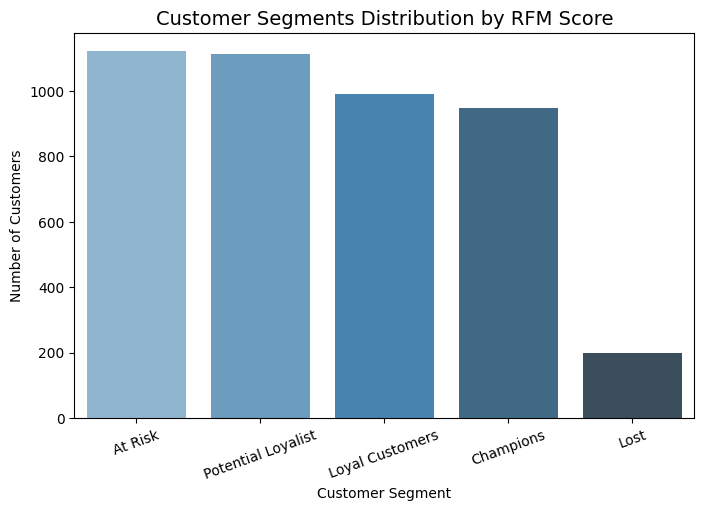

In [20]:
segment_counts = Rec_freq_monetary['Customer_Segment'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='Blues_d')
plt.title('Customer Segments Distribution by RFM Score', fontsize=14)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.show()

## RFM Distribution Analysis

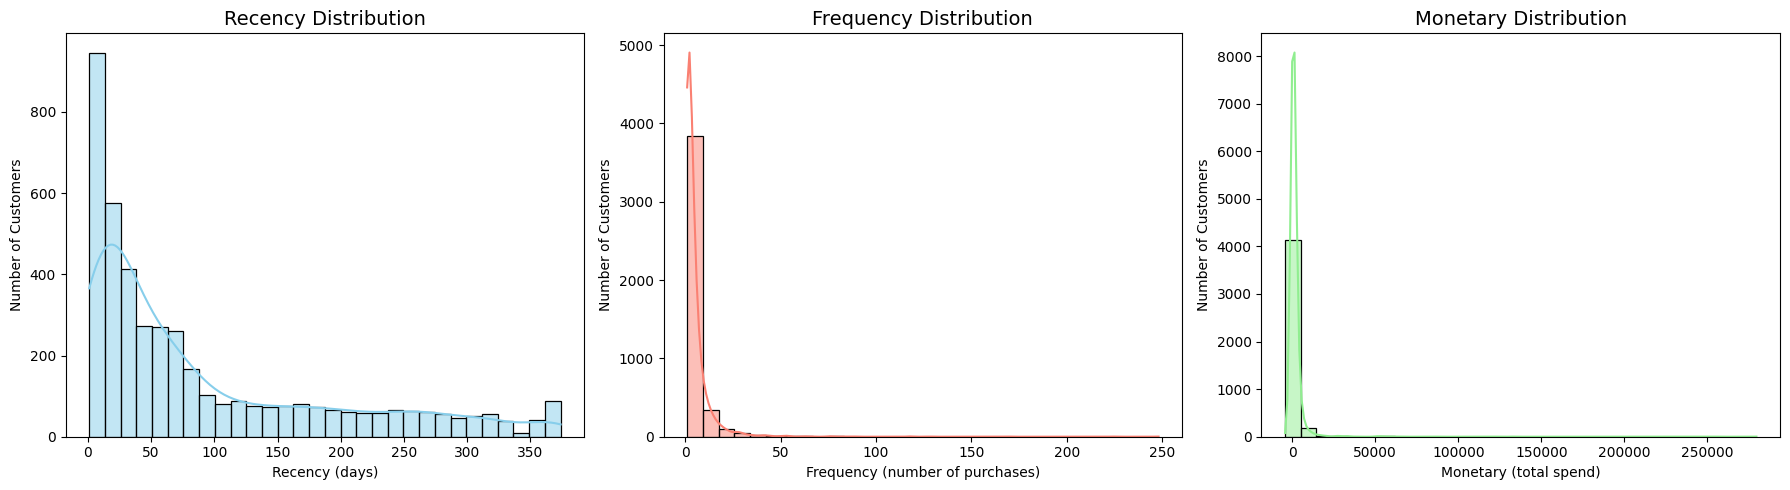

In [21]:
# RFM Distribution Visualization
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
sns.histplot(Rec_freq_monetary['Recency'], bins=30, kde=True, color='skyblue')
plt.title('Recency Distribution', fontsize=14)
plt.xlabel('Recency (days)')
plt.ylabel('Number of Customers')
plt.subplot(1,3,2)
sns.histplot(Rec_freq_monetary['Frequency'], bins=30, kde=True, color='salmon')
plt.title('Frequency Distribution', fontsize=14)
plt.xlabel('Frequency (number of purchases)')
plt.ylabel('Number of Customers')
plt.subplot(1,3,3)
sns.histplot(Rec_freq_monetary['Monetary'], bins=30, kde=True, color='lightgreen')
plt.title('Monetary Distribution', fontsize=14)
plt.xlabel('Monetary (total spend)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

## RFM Heatmap
Creating a heatmap showing the relationship between Recency and Frequency scores, with Monetary value as the color intensity.

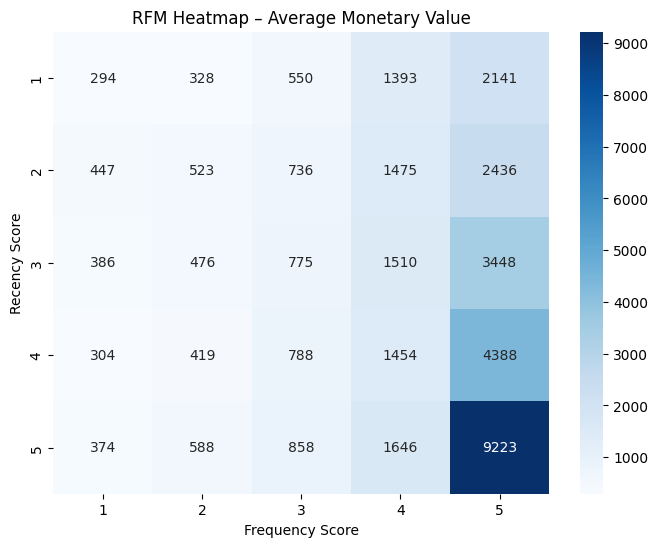

In [22]:
rfm_heatmap = Rec_freq_monetary.pivot_table(
    index='R_score', 
    columns='F_score', 
    values='Monetary', 
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(rfm_heatmap, cmap='Blues', annot=True, fmt=".0f")
plt.title('RFM Heatmap – Average Monetary Value')
plt.xlabel('Frequency Score')
plt.ylabel('Recency Score')
plt.show()

## Segment Comparison
Comparing average RFM values across different customer segments to understand their characteristics.

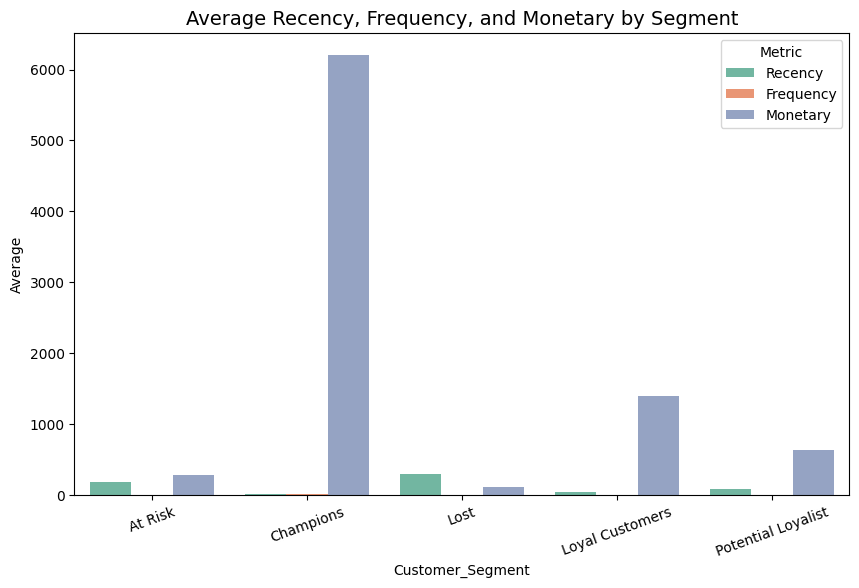

In [23]:
segment_avg = Rec_freq_monetary.groupby('Customer_Segment')[['Recency','Frequency','Monetary']].mean().reset_index()

segment_avg_melted = segment_avg.melt(id_vars='Customer_Segment', var_name='Metric', value_name='Average')
plt.figure(figsize=(10,6))
sns.barplot(data=segment_avg_melted, x='Customer_Segment', y='Average', hue='Metric', palette='Set2')
plt.title('Average Recency, Frequency, and Monetary by Segment', fontsize=14)
plt.xticks(rotation=20)
plt.show()


## Customer Segment Analysis & Insights

In [24]:
# Display segment statistics
segment_summary = Rec_freq_monetary.groupby('Customer_Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean', 
    'Monetary': 'mean'
}).round(2)

segment_summary.columns = ['Customer Count', 'Avg Recency (days)', 'Avg Frequency', 'Avg Monetary (£)']
print("Customer Segment Summary:")
print("=" * 50)
segment_summary

Customer Segment Summary:


,Customer Count,Avg Recency (days),Avg Frequency,Avg Monetary (£)
Customer_Segment,,,,
At Risk,1121,176.95,1.30,279.20
Champions,949,13.49,14.10,6206.01
Lost,198,290.10,1.00,111.18
Loyal Customers,990,43.13,4.61,1390.12
Potential Loyalist,1114,81.81,2.32,627.78


## Customer Value Analysis

In [25]:
# Calculate revenue contribution by segment
segment_revenue = Rec_freq_monetary.groupby('Customer_Segment').agg({
    'CustomerID': 'count',
    'Monetary': ['sum', 'mean']
}).round(2)

segment_revenue.columns = ['Customer_Count', 'Total_Revenue', 'Avg_Revenue_Per_Customer']
segment_revenue['Revenue_Percentage'] = (segment_revenue['Total_Revenue'] / segment_revenue['Total_Revenue'].sum() * 100).round(2)

print("Revenue Analysis by Customer Segment:")
print("=" * 50)
segment_revenue

Revenue Analysis by Customer Segment:


,Customer_Count,Total_Revenue,Avg_Revenue_Per_Customer,Revenue_Percentage
Customer_Segment,,,,
At Risk,1121,312987.46,279.20,3.77
Champions,949,5889501.35,6206.01,70.96
Lost,198,22014.18,111.18,0.27
Loyal Customers,990,1376221.27,1390.12,16.58
Potential Loyalist,1114,699341.55,627.78,8.43


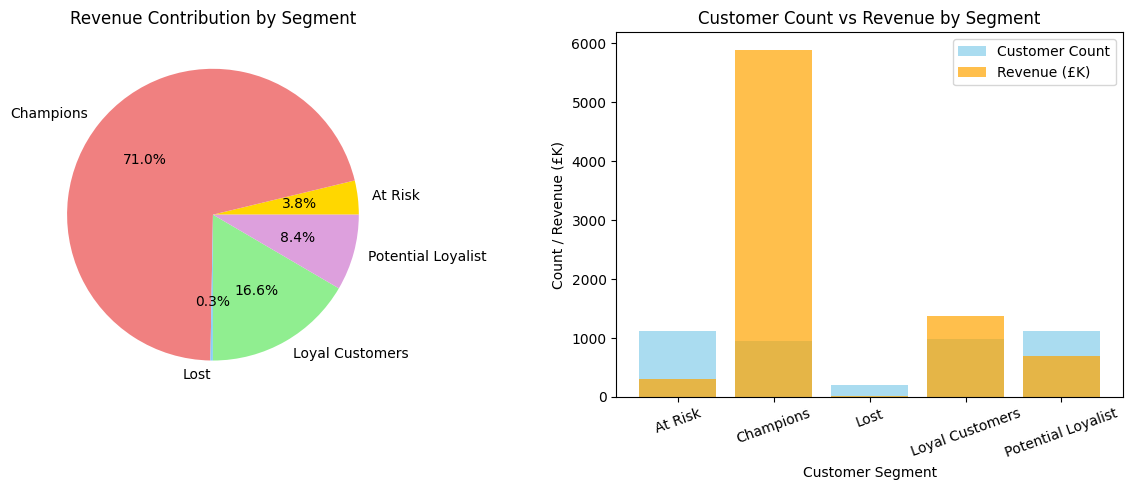

In [26]:
# Visualize revenue contribution
plt.figure(figsize=(12,5))

# Revenue pie chart
plt.subplot(1,2,1)
plt.pie(segment_revenue['Revenue_Percentage'], labels=segment_revenue.index, autopct='%1.1f%%', 
        colors=['gold', 'lightcoral', 'lightskyblue', 'lightgreen', 'plum'])
plt.title('Revenue Contribution by Segment')

# Customer count vs revenue
plt.subplot(1,2,2)
segments = segment_revenue.index
x_pos = range(len(segments))
plt.bar(x_pos, segment_revenue['Customer_Count'], alpha=0.7, color='skyblue', label='Customer Count')
plt.bar(x_pos, segment_revenue['Total_Revenue']/1000, alpha=0.7, color='orange', label='Revenue (£K)')
plt.xlabel('Customer Segment')
plt.ylabel('Count / Revenue (£K)')
plt.title('Customer Count vs Revenue by Segment')
plt.xticks(x_pos, segments, rotation=20)
plt.legend()

plt.tight_layout()
plt.show()